<h1>Livrable 2.3 : Analyse exploratoire, descriptive et inférentielle de données</h1>

> **Livrable attendu :** Deux codes sources décrivant l'analyse de chacune des bases de données, incluant la construction de graphiques.

# EDA Dataset Frame-Wise

L'exécution de ce notebook a pour prérequis :

- le téléchargement des dépendances :
  
  ```bash
  uv sync --group audio_midi --group api
  ```

- le téléchargement du dataset `GuitarSet` :
  
  ```bash
  uv run ./audio_midi/main.py --download_datasets --no_idmt_smt_guitar
  ```

- le démarrage de l'infrastructure docker :
  
  ```bash
  cp .env.exemple .env
  docker-compose up -d
  ```
  
- l'ingestion du dataset `GuitarSet` :
  
  ```bash
  uv run ./audio_midi/main.py --ingest_guitar_set
  ```
  
- le prétraitement du dataset `GuitarSet` :
  
  ```bash
  uv run ./audio_midi/main.py --preprocess_datasets --no_idmt_smt_guitar
  ```


## Imports

In [1]:
import sys
from pathlib import Path

APP_DIR = Path.cwd().parent
sys.path.append(APP_DIR.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = APP_DIR / "output"
EDA_DATASET_FRAME_WISE_DIRECTORY = OUTPUT_DIRECTORY / "eda_dataset_frame_wise"
FIGURES_DIRECTORY = EDA_DATASET_FRAME_WISE_DIRECTORY / "figures"
LATEX_DIRECTORY = EDA_DATASET_FRAME_WISE_DIRECTORY / "latex"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
EDA_DATASET_FRAME_WISE_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LATEX_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
import warnings

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")

RANDOM_STATE = 73
np.random.seed(RANDOM_STATE)

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports dataset builder
import logging

from src.pipelines import DatasetBuilderPipeline
from settings.dataset_builder_pipeline_settings import DatasetBuilderPipelineSettings

## Chargement des données

In [6]:
settings_standard = DatasetBuilderPipelineSettings()
dataset_builder_pipeline = DatasetBuilderPipeline(
    logging.getLogger(), settings=settings_standard
)

(X_train, y_train), (X_validation, y_validation), (X_test, y_test) = (
    dataset_builder_pipeline.run()
)

## Description générale du dataset

In [7]:
print(
    "Nombre de valeurs manquantes dans le jeu d'entraînement :",
    X_train.isna().sum().sum(),
)
print(
    "Nombre de valeurs manquantes dans le jeu de validation  :",
    X_validation.isna().sum().sum(),
)
print(
    "Nombre de valeurs manquantes dans le jeu de test        :",
    X_test.isna().sum().sum(),
)

Nombre de valeurs manquantes dans le jeu d'entraînement : 0
Nombre de valeurs manquantes dans le jeu de validation  : 0
Nombre de valeurs manquantes dans le jeu de test        : 0


In [8]:
dataset_size = len(X_train) + len(X_validation) + len(X_test)
print("Nombre total de lignes du dataset :", dataset_size)
print()

print("Jeu d'entraînement :")
train_size = len(X_train)
print(
    f"  Nombre de frames   : {train_size}   ({train_size / dataset_size * 100:.2f}% du dataset)"
)
print("  Nombre de CQT bins :", X_train.shape[1])
print("  Nombre de pitches  :", y_train.shape[1])
print()

print("Jeu de validation :")
validation_size = len(X_validation)
print(
    f"  Nombre de frames   : {validation_size}   ({validation_size / dataset_size * 100:.2f}% du dataset)"
)
print("  Nombre de CQT bins :", X_validation.shape[1])
print("  Nombre de pitches  :", y_validation.shape[1])
print()

print("Jeu de test :")
test_size = len(X_test)
print(
    f"  Nombre de frames   : {test_size}   ({test_size / dataset_size * 100:.2f}% du dataset)"
)
print("  Nombre de CQT bins :", X_test.shape[1])
print("  Nombre de pitches  :", y_test.shape[1])

Nombre total de lignes du dataset : 472560

Jeu d'entraînement :
  Nombre de frames   : 342529   (72.48% du dataset)
  Nombre de CQT bins : 84
  Nombre de pitches  : 49

Jeu de validation :
  Nombre de frames   : 38591   (8.17% du dataset)
  Nombre de CQT bins : 84
  Nombre de pitches  : 49

Jeu de test :
  Nombre de frames   : 91440   (19.35% du dataset)
  Nombre de CQT bins : 84
  Nombre de pitches  : 49


## Analyse des features CQT

### Analyse de la distribution globale

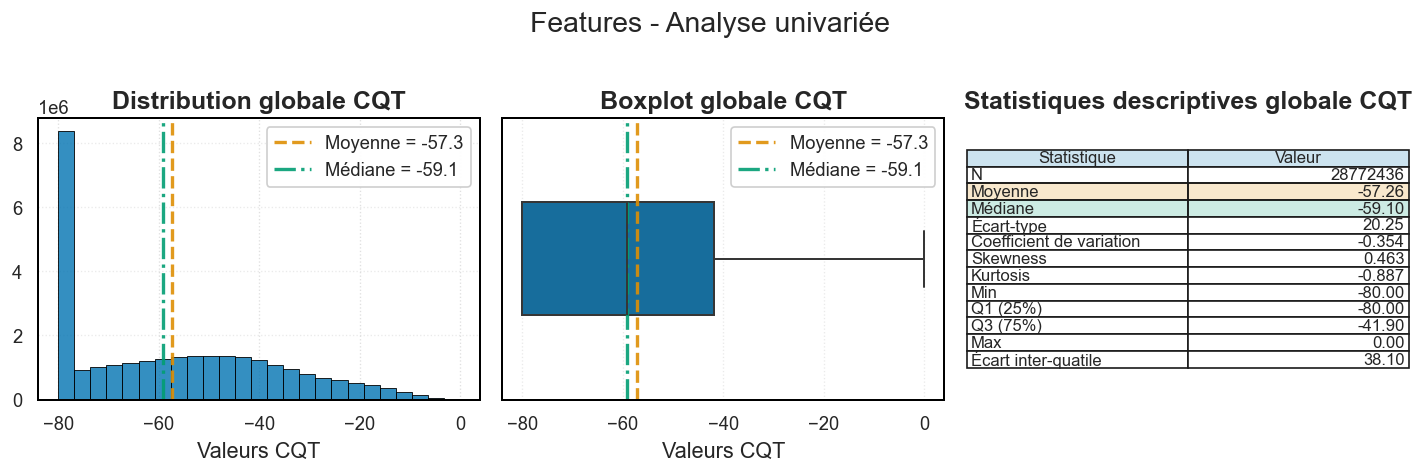

In [9]:
def create_histplot(ax, values):
    sns.histplot(
        x=values,
        # bins=int(np.sqrt(len(values))),
        bins=int(1 + np.log2(len(values))),
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = np.mean(values)
    median_column = np.median(values)

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, values):
    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = np.mean(values)
    median_val = np.median(values)

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    mean_val = np.mean(values)
    std_val = np.std(values)
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = stats.skew(values)
    kurt = stats.kurtosis(values)
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{np.median(values):.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{np.min(values):.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{np.max(values):.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

fig.suptitle("Features - Analyse univariée", fontsize=17)

ax1 = axes[0]
create_histplot(ax1, X_train.values.ravel())
ax1.set_title("Distribution globale CQT")
ax1.set_xlabel("Valeurs CQT")
ax1.set_ylabel(None)

ax2 = axes[1]
create_boxplot(ax2, X_train.values.ravel())
ax2.set_title("Boxplot globale CQT")
ax2.set_xlabel("Valeurs CQT")

ax3 = axes[2]
create_stats_panel(ax3, X_train.values.ravel())
ax3.set_title("Statistiques descriptives globale CQT")

fig.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "global_distribution_cqt.png").as_posix())
plt.show()

Observations :
- L'histogramme montre un pic massif à -80 dB, qui correspond très probablement à la valeur plancher appliquée lors du calcul du spectrogramme CQT. La distribution est donc fortement censurée. Le fait que $Q1 = -80$ indique qu'au moins 25% des valeurs sont exactement au plancher.
- Le fait que la moyenne soit légérement supérieure à la médiane (-57.26 > -59.10) et que le skewness soit strictement positif (0.463) indique une légère asymétrie positive. Cela indique une queue plus lourde vers les fortes valeurs (0 db).
- Le kurtosis négatif (-0.887) montre une distribution plus plate qu'une gaussienne. Cela suggère que les valeurs énergétiques sont réparties sur une large plage.
- Le boxplot ne révèle pas de valeurs extrêmes mais montre un intervalle interquartile grand. Ce qui signifie que la variablité est importante.

Conclusions :
- Le dataset contient énormément de bins temps-fréquence sans énergie, cela implique un fort déséquilibre des données.
- Le modèle verra peu d'événements musicaux et risque de ne pas détecter l'activation des notes.
- Un normalisation min-max ne serait pas idéale, il faudra privilégier une standardisation robuste : $x' = \dfrac{x - médiane}{IQR}$.

### Analyse des corrélations

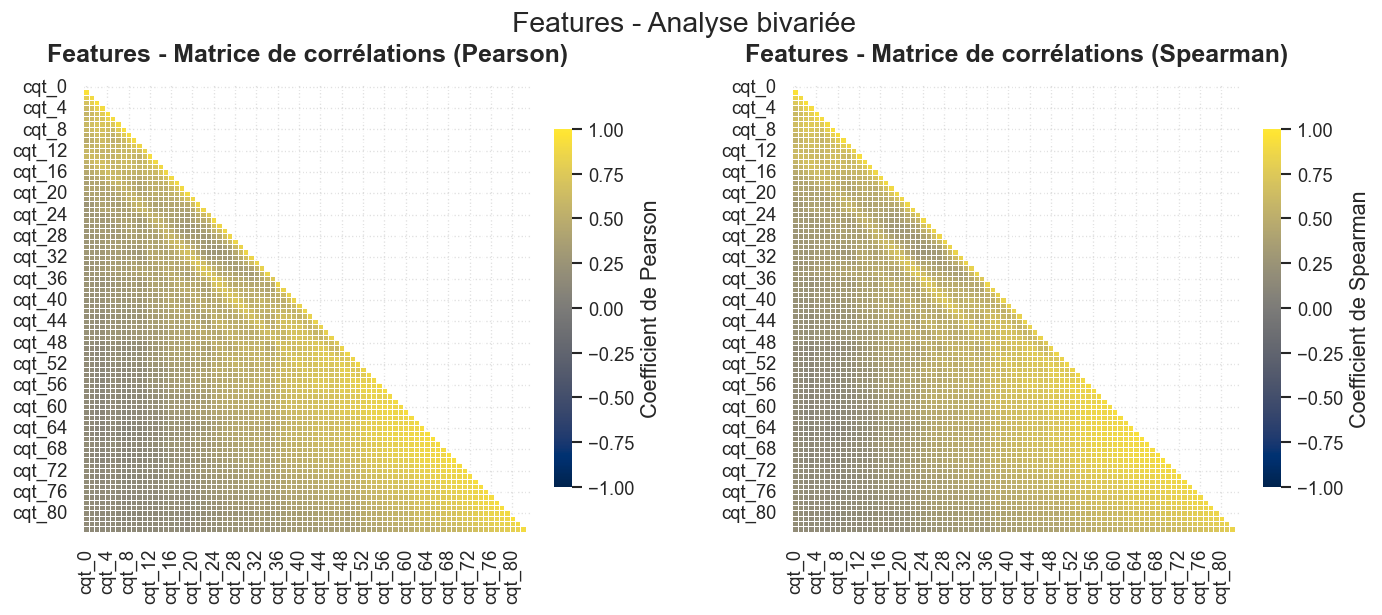

In [10]:
X_train_sample = X_train.sample(5000)

features_corr_df_pearson = X_train_sample.corr(method="pearson")
features_corr_df_spearman = X_train_sample.corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Features - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    features_corr_df_pearson,
    mask=np.triu(np.ones_like(features_corr_df_pearson, dtype=bool)),
    annot=False,
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Features - Matrice de corrélations (Pearson)", pad=14)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    features_corr_df_spearman,
    mask=np.triu(np.ones_like(features_corr_df_spearman, dtype=bool)),
    annot=False,
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Features - Matrice de corrélations (Spearman)", pad=14)

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "features_correlations.png").as_posix())
plt.show()

Obsesrvations :
- Les matrices de corrélations révèlent de fortes corrélations entre les variables.
- La similarités des matrices de corrélations de Pearson et Spearman indiquent que les relations entre variables sont probablement linéaires.

Conclusion :
- Une PCA peut être envisagée.

### PCA

In [11]:
scaler = RobustScaler()
X_train_normalized = scaler.fit_transform(X_train)

pca = PCA()
pca.fit_transform(X_train_normalized)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

In [12]:
n_80pct = (cumulative_variance >= 0.80).argmax() + 1
n_90pct = (cumulative_variance >= 0.90).argmax() + 1
n_99pct = (cumulative_variance >= 0.99).argmax() + 1
n_kaiser = sum(pca.explained_variance_ > 1)

print(f"Nombre de composantes pour au moins 80% de variance : {n_80pct}")
print(f"Nombre de composantes pour au moins 90% de variance : {n_90pct}")
print(f"Nombre de composantes pour au moins 99% de variance : {n_99pct}")
print(f"Nombre de valeurs propres supérieures à 1 (Kaiser)   : {n_kaiser}")

n_components = max(n_90pct, n_kaiser)
print(
    f"\n>>> DÉCISION : {n_components} composantes ({cumulative_variance[n_components - 1] * 100:.1f}% de variance)"
)

Nombre de composantes pour au moins 80% de variance : 2
Nombre de composantes pour au moins 90% de variance : 5
Nombre de composantes pour au moins 99% de variance : 35
Nombre de valeurs propres supérieures à 1 (Kaiser)   : 6

>>> DÉCISION : 6 composantes (92.4% de variance)


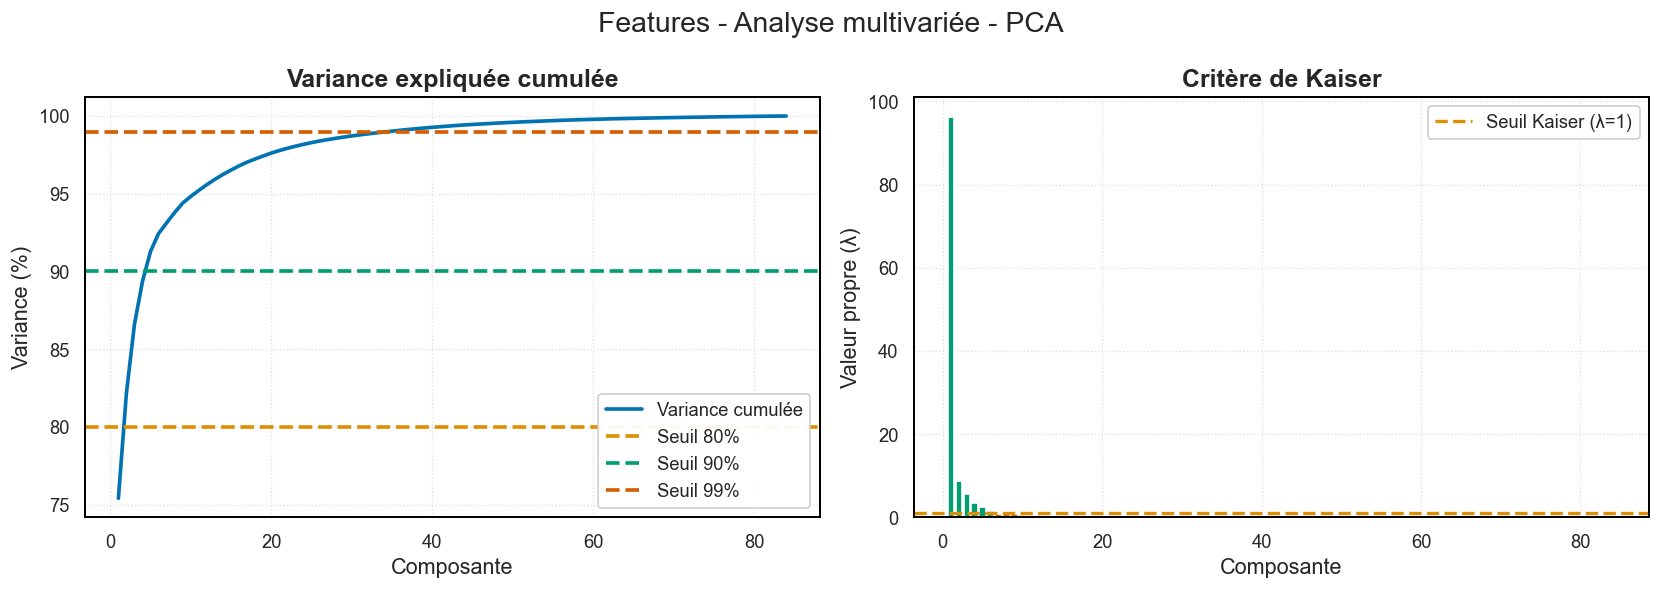

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("Features - Analyse multivariée - PCA", fontsize=17)

x = range(1, len(pca.explained_variance_) + 1)
ax1.plot(x, cumulative_variance * 100, label="Variance cumulée")
ax1.axhline(80, color=COLORBLIND_PALETTE[1], linestyle="--", label="Seuil 80%")
ax1.axhline(90, color=COLORBLIND_PALETTE[2], linestyle="--", label="Seuil 90%")
ax1.axhline(99, color=COLORBLIND_PALETTE[3], linestyle="--", label="Seuil 99%")
ax1.set_xlabel("Composante")
ax1.set_ylabel("Variance (%)")
ax1.set_title("Variance expliquée cumulée")
ax1.legend()

colors = [
    COLORBLIND_PALETTE[2] if lam > 1 else COLORBLIND_PALETTE[3]
    for lam in pca.explained_variance_
]
ax2.bar(x, pca.explained_variance_, color=colors)
ax2.axhline(
    1,
    color=COLORBLIND_PALETTE[1],
    linestyle="--",
    linewidth=2,
    label="Seuil Kaiser (λ=1)",
)
ax2.set_xlabel("Composante")
ax2.set_ylabel("Valeur propre (λ)")
ax2.set_title("Critère de Kaiser", fontweight="bold")
ax2.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "pca.png").as_posix())
plt.show()

In [14]:
loadings = pca.components_

df_loadings = pd.DataFrame(
    loadings[:n_components].T,
    columns=[f"PC{k}" for k in range(1, n_components + 1)],
    index=X_train.columns,
)

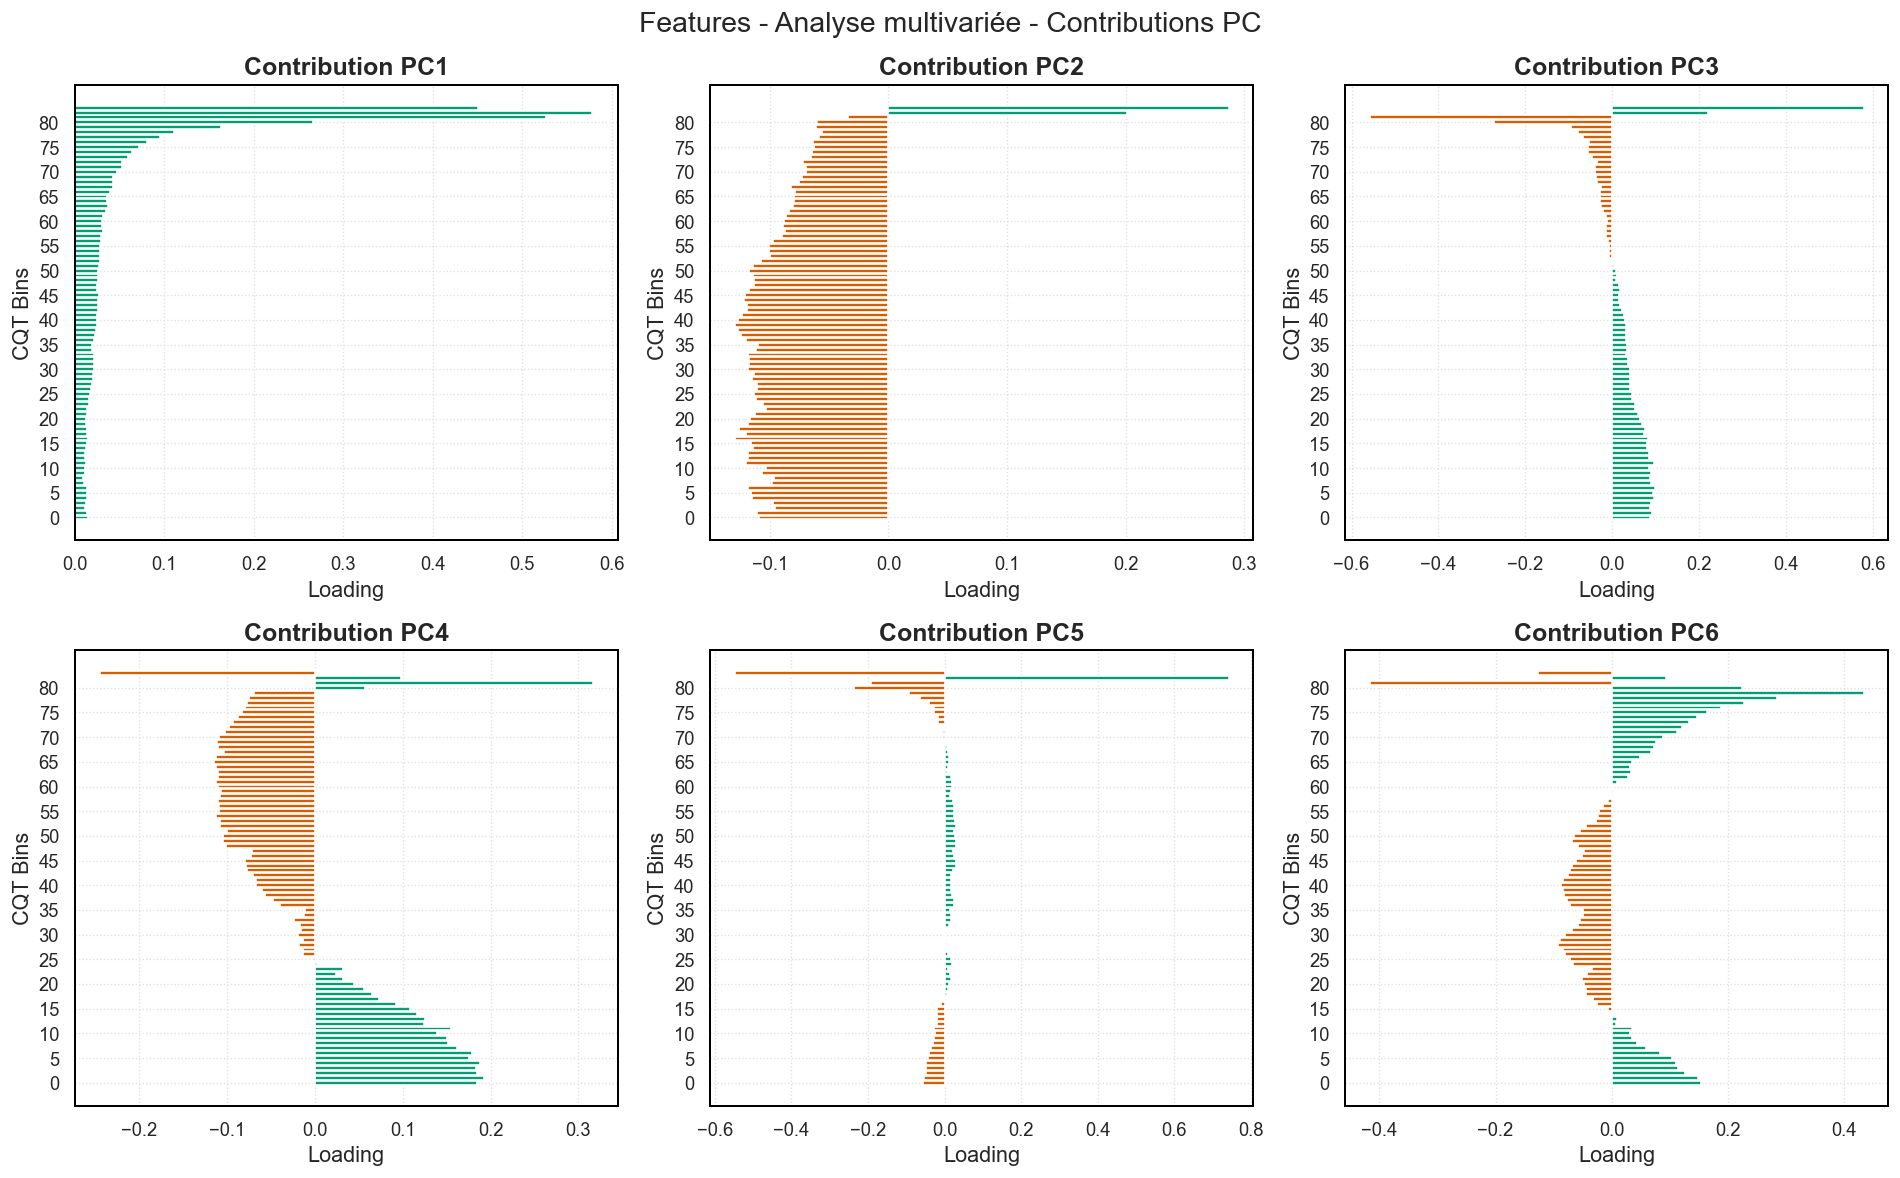

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plt.suptitle("Features - Analyse multivariée - Contributions PC", fontsize=17)

axes = axes.flatten()

for k in range(n_components):
    colors_pc = [
        COLORBLIND_PALETTE[3] if x < 0 else COLORBLIND_PALETTE[2]
        for x in df_loadings[f"PC{k + 1}"]
    ]
    axes[k].barh(df_loadings.index, df_loadings[f"PC{k + 1}"], color=colors_pc)
    axes[k].set_title(f"Contribution PC{k + 1}")
    axes[k].set_xlabel("Loading")
    axes[k].set_yticks(
        np.arange(0, len(df_loadings), 5), np.arange(0, len(df_loadings), 5)
    )
    axes[k].set_ylabel("CQT Bins")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "pca_contributions.png").as_posix())
plt.show()

## Analyse des activation de pitch

In [16]:
activation_count = y_train.sum(axis=0)
activation_rate = y_train.mean(axis=0)

print("Nombre de pitch sans activation :", np.sum(activation_count == 0))
print("Liste de pitch sans activation  :")
print(f"  {activation_count[activation_count == 0].index.tolist()}")

Nombre de pitch sans activation : 7
Liste de pitch sans activation  :
  ['midi_pitch_82', 'midi_pitch_83', 'midi_pitch_84', 'midi_pitch_85', 'midi_pitch_86', 'midi_pitch_87', 'midi_pitch_88']


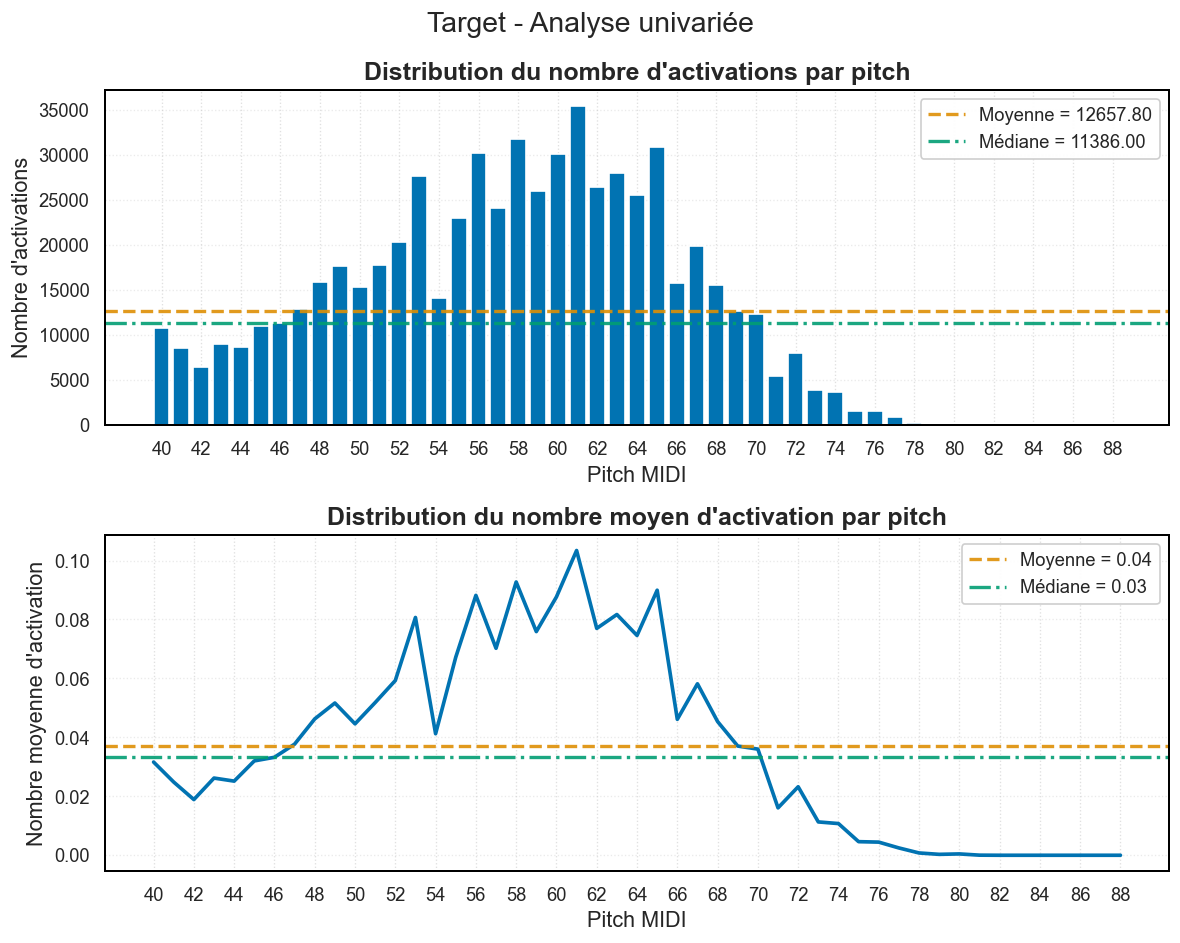

In [17]:
def create_barplot(ax: plt.Axes, serie: pd.Series, rotation: int = 0):
    ax.bar(serie.index, serie.values)

    mean_column = np.mean(serie.values)
    median_column = np.median(serie.values)

    ax.axhline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.2f}",
    )

    ax.axhline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.2f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


def create_plot(ax: plt.Axes, serie: pd.Series, rotation: int = 0):
    ax.plot(serie.index, serie.values)

    mean_column = np.mean(serie.values)
    median_column = np.median(serie.values)

    ax.axhline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.2f}",
    )

    ax.axhline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.2f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


pitch_offset = int(activation_count.index[0].replace("midi_pitch_", ""))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

fig.suptitle("Target - Analyse univariée", fontsize=17)

create_barplot(ax1, activation_count)
ax1.set_title("Distribution du nombre d'activations par pitch")
ax1.set_xlabel("Pitch MIDI")
ax1.set_xticks(
    np.arange(0, len(activation_count), 2),
    np.arange(pitch_offset, pitch_offset + len(activation_count), 2),
)
ax1.set_ylabel("Nombre d'activations")

create_plot(ax2, activation_rate)
ax2.set_title("Distribution du nombre moyen d'activation par pitch")
ax2.set_xlabel("Pitch MIDI")
ax2.set_xticks(
    np.arange(0, len(activation_rate), 2),
    np.arange(pitch_offset, pitch_offset + len(activation_rate), 2),
)
ax2.set_ylabel("Nombre moyenne d'activation")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "activation_pitch_analysis.png").as_posix())
plt.show()

Observations :
- Distribution du nombre d'activation par pitch :
  - Le distribution du nombre d'activations par pitch est inégale.
  - 7 pitch ne sont pas activés.
- Distribution du nombre moyen d'activation par pitch :
  - Pour chaque pitch, le déséquilibre entre activation et non-activation est très important. En moyenne 4% d'activation par pitch.

Conclusion :
- Le modèle peut avoir plus de difficultés à détecter certains pitches en raison du faible nombre d'activations.
- Le déséquilibre des classes est un réel problème, le modèle risque de ne pas détecter d'activation.

### Polyphonie

In [18]:
polyphony = y_train.sum(axis=1)

print("Statistiques descriptives polyphonie :")
print(f"  Nombre moyen de notes simultanées         : {polyphony.mean():.2f}")
print(f"  Ecart-type du nombre de notes simultanées : {polyphony.std():.2f}")
print(f"  Nombre minimal de notes simultanées       : {polyphony.min()}")
print(f"  Nombre médian de notes simultanées        : {polyphony.median()}")
print(f"  Nombre maximal de notes simultanées       : {polyphony.max()}")
print()

print("Erreur de construction du piano-roll :")
print(
    "  Nombre de frame ayant plus de 6 notes actives :", len(polyphony[polyphony > 6])
)

Statistiques descriptives polyphonie :
  Nombre moyen de notes simultanées         : 1.81
  Ecart-type du nombre de notes simultanées : 1.55
  Nombre minimal de notes simultanées       : 0
  Nombre médian de notes simultanées        : 1.0
  Nombre maximal de notes simultanées       : 8

Erreur de construction du piano-roll :
  Nombre de frame ayant plus de 6 notes actives : 63


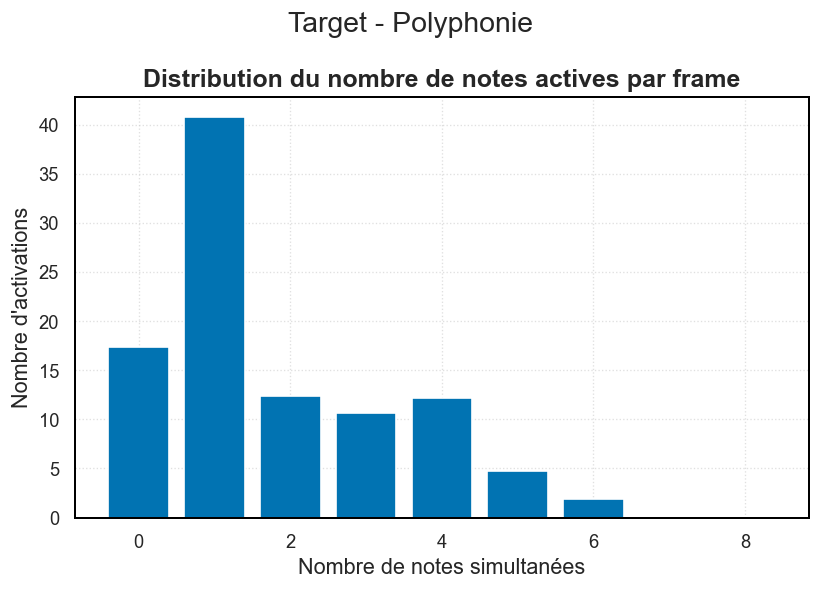

In [19]:
polyphony_count = polyphony.value_counts()
polyphony_rate = polyphony_count / polyphony_count.sum() * 100

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))

fig.suptitle("Target - Polyphonie", fontsize=17)

ax1.bar(polyphony_rate.index, polyphony_rate.values)
ax1.set_title("Distribution du nombre de notes actives par frame")
ax1.set_xlabel("Nombre de notes simultanées")
ax1.set_ylabel("Nombre d'activations")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "distibution_simultaneous_activations.png").as_posix())
plt.show()

Observations :
- 63 frames contiennent plus de 6 notes, ce qui constitue une erreur lors de la construction du dataset.
- La polyphonie moyenne est de 1.81 ($\pm$ 1.55) notes actives par frames. Environ 60% des frames contiennent au plus une activation. La polyphonie constitue environ 40% des frames.

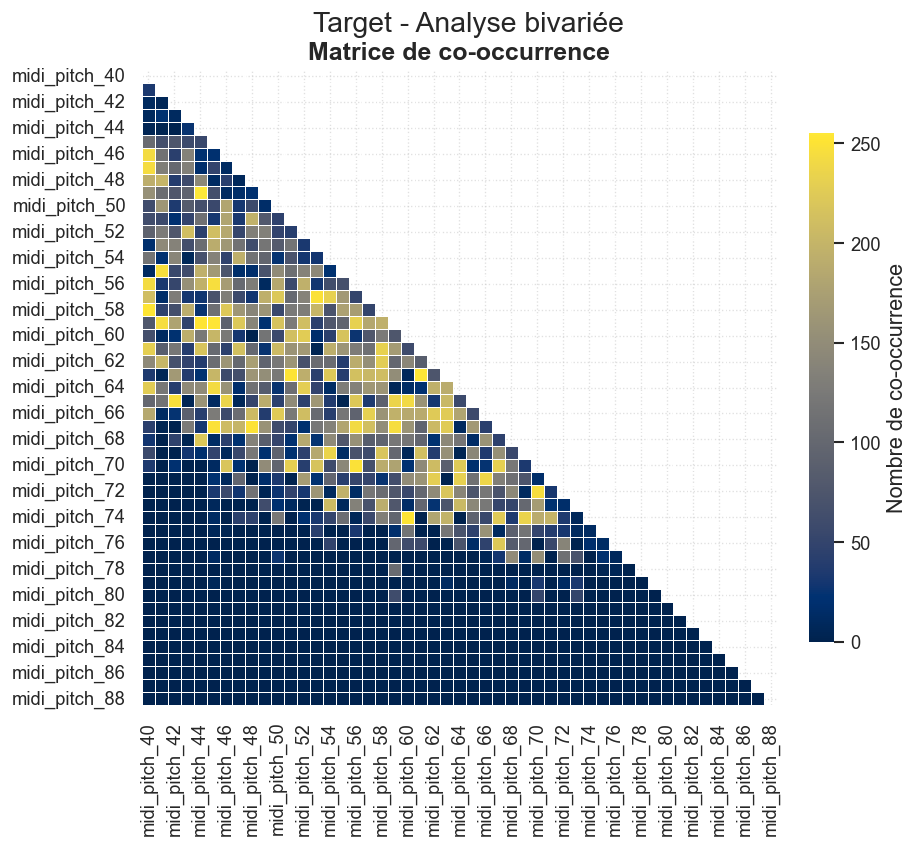

In [20]:
co_occurrence_matrix = y_train.T @ y_train

fig, ax1 = plt.subplots(1, 1, figsize=(8, 7))

fig.suptitle("Target - Analyse bivariée", fontsize=17)

heatmap = sns.heatmap(
    co_occurrence_matrix,
    mask=np.triu(np.ones_like(co_occurrence_matrix, dtype=bool)),
    annot=False,
    cmap="cividis",
    vmin=0,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Nombre de co-occurrence"},
    annot_kws={"size": 10},
)
ax1.set_title("Matrice de co-occurrence")

plt.tight_layout()
plt.show()

Observations :
- Certains couples de pitches sont activés plus fréquemment que d'autres. On retrouve par exemple des intervalles de quarte (44 - 49), des intervalles de quinte (40 - 47) ou de neuvième (60 - 74).

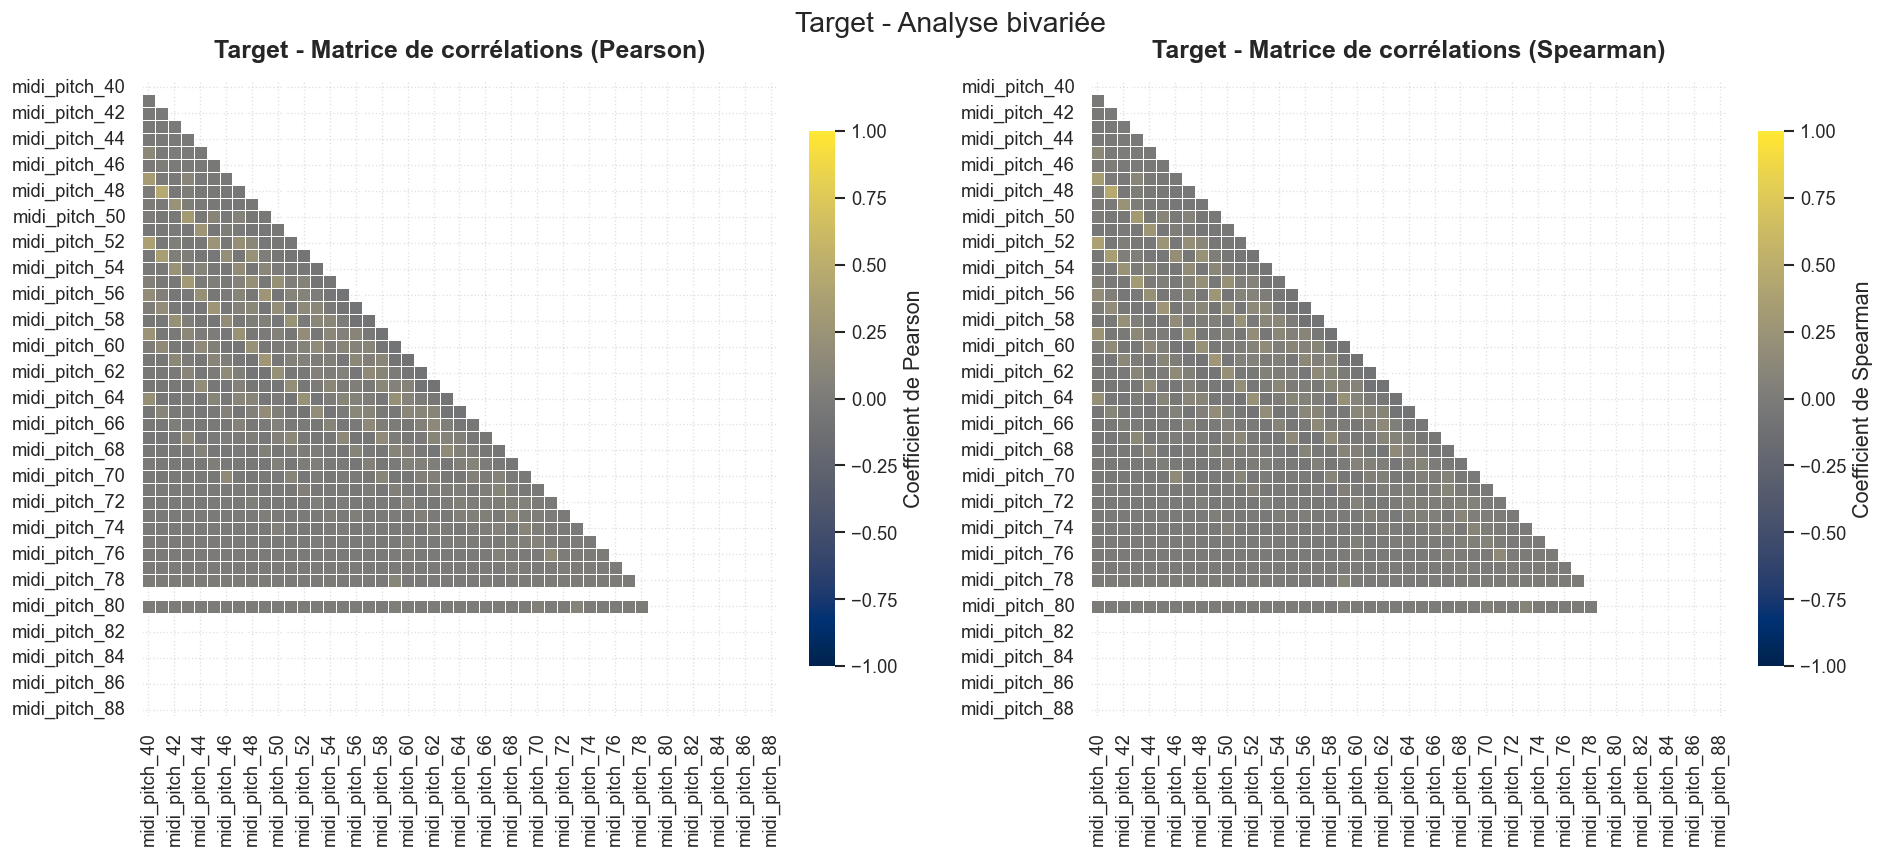

In [21]:
y_train_sample = y_train.sample(5000)

target_corr_df_pearson = y_train_sample.corr(method="pearson")
target_corr_df_spearman = y_train_sample.corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

fig.suptitle("Target - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    target_corr_df_pearson,
    mask=np.triu(np.ones_like(target_corr_df_pearson, dtype=bool)),
    annot=False,
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Target - Matrice de corrélations (Pearson)", pad=14)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    target_corr_df_spearman,
    mask=np.triu(np.ones_like(target_corr_df_spearman, dtype=bool)),
    annot=False,
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Target - Matrice de corrélations (Spearman)", pad=14)

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "target_correlations.png").as_posix())
plt.show()

Observations :
- On observes des corrélations sur des intervalles fréquemment joués. Par exemple la diagonale passant par (40; 47) correspond à un interval de quinte, le diagonale passant par (40; 52) correspond à un intervalle d'octave, ... 

## Analyse CQT vs Pitch

In [22]:
pitch = 40  # /!\ Entre 40 et 88

active = X_train[y_train[f"midi_pitch_{pitch}"] == 1]
inactive = X_train[y_train[f"midi_pitch_{pitch}"] == 0]

mutual_information = mutual_info_classif(
    X_train, y_train[f"midi_pitch_{pitch}"].astype(int)
)

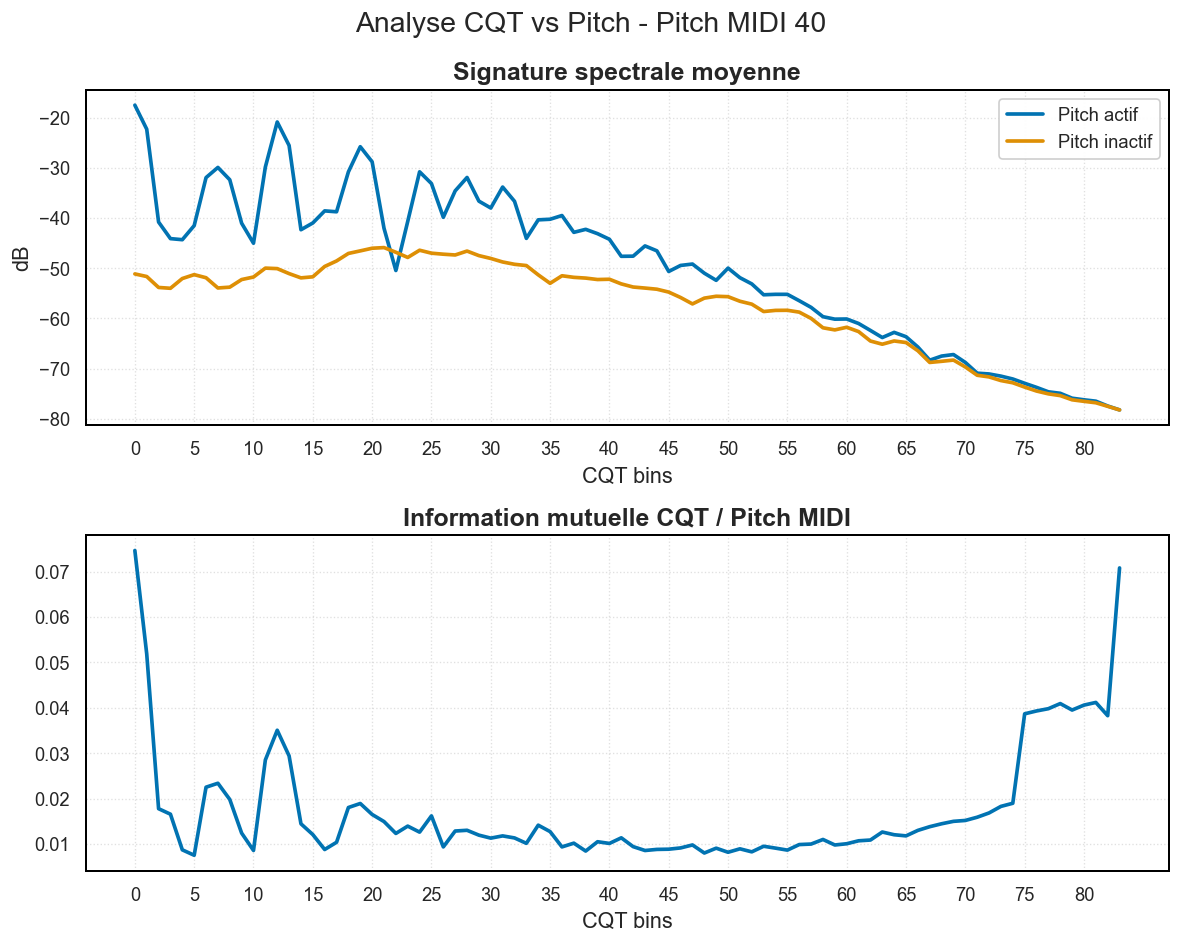

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

fig.suptitle(f"Analyse CQT vs Pitch - Pitch MIDI {pitch}", fontsize=17)

ax1.plot(active.mean(axis=0), label="Pitch actif")
ax1.plot(inactive.mean(axis=0), label="Pitch inactif")
ax1.legend()

ax1.set_title("Signature spectrale moyenne")
ax1.set_xticks(
    np.arange(0, len(active.columns), 5), np.arange(0, len(active.columns), 5)
)
ax1.set_xlabel("CQT bins")
ax1.set_ylabel("dB")

ax2.plot(mutual_information)

ax2.set_title("Information mutuelle CQT / Pitch MIDI")
ax2.set_xticks(
    np.arange(0, len(mutual_information), 5), np.arange(0, len(mutual_information), 5)
)
ax2.set_xlabel("CQT bins")

fig.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "cqt_vs_pitch.png").as_posix())
fig.show()